In [49]:
using SimpleEvolve
using NPZ
using Plots
using LinearAlgebra
using Optim
using LineSearches
using Random
using JLD2
using DSP   
using Arpack
using FFTW
using Interpolations
using Statistics

#### Tutorial — Bandlimited Pulse Optimization in the Slepian Basis

This notebook walks through a **variational pulse-level VQE** that finds the ground state of a molecular Hamiltonian (LiH at 1.50 Å) by optimizing microwave drives on a 4-transmon device.

The four moving pieces are:

1. **Device:** A linear chain of 4 coupled transmons (qubits) with different pulse drive on each.

2. **Control basis:** Instead of free time-series samples, the real and imaginary drive envelopes are parameterised in the **discrete prolate spheroidal sequence (DPSS / Slepian)** basis. This enforces the `[-B, +B]` GHz bandwidth constraint *by construction*.

3. **Cost:** $E(\vec c)=\langle\psi(T;\vec c)|\,\hat H_{\text{mol}}\,|\psi(T;\vec c)\rangle$ plus a smooth amplitude penalty that suppresses drives beyond a target `Ω₀`.

4. **Gradient:** **Computed analytically** —- one forward + one backward Schrödinger ODE solve gives the full $(N{+}1)\times n_q$ sample-gradient, then a linear map $\Phi^\top$ projects it back to Slepian-coefficient space. Total cost per gradient: 2 ODE solves, independent of the number of parameters.


In [50]:
# ----------------------------
# User / device parameters #
# ----------------------------
T = 25.0 # in ns
println("T=", T)
Cost_ham = npzread("./../lih15/lih15.npy") 
n_qubits = round(Int, log2(size(Cost_ham, 1)))
println("n_qubits=", n_qubits)
n_levels = 2
SYSTEM = "lih-1.5"
freqs = 2π * collect(4.8 .+ (0.02 * (1:n_qubits)))
anharmonicities = 2π * 0.3 * ones(n_qubits)
coupling_map = Dict{QubitCoupling,Float64}()
# linear chain coupling map with nearest neighbor coupling of 0.02 GHz
for p in 1:n_qubits
    q = (p == n_qubits) ? 1 : p + 1
    coupling_map[QubitCoupling(p, q)] = 2π * 0.02
end
device = Transmon(freqs, anharmonicities, coupling_map, n_qubits)

T=25.0
n_qubits=4


Transmon(4, [30.2849531806056, 30.410616886749196, 30.536280592892787, 30.66194429903638], [1.8849555921538759, 1.8849555921538759, 1.8849555921538759, 1.8849555921538759], Dict{QubitCoupling, Float64}(QubitCoupling(3, 4) => 0.12566370614359174, QubitCoupling(1, 2) => 0.12566370614359174, QubitCoupling(2, 3) => 0.12566370614359174, QubitCoupling(1, 4) => 0.12566370614359174))

#### 1. Device Hamiltonian

The static (drift) Hamiltonian is the usual Bose–Hubbard transmon lattice:

$$
\hat{H}_0 \;=\; \sum_{q=1}^{n} \omega_q\, \hat a^\dagger_q \hat a_q
 \;-\; \tfrac{\delta_q}{2}\, \hat a^\dagger_q \hat a^\dagger_q \hat a_q \hat a_q
 \;+\; \sum_{(p,q)\in\mathcal{E}} g_{pq}\bigl(\hat a^\dagger_p \hat a_q + \hat a_p \hat a^\dagger_q\bigr)
$$

- $\omega_q = 2\pi\,(4.80 + 0.02\,q)$ GHz — qubit frequencies (detuned so each drive addresses one qubit).
- $\delta_q = 2\pi \cdot 0.3$ GHz — anharmonicity (here we truncate to `n_levels = 2`, so this only sets the energy scale).
- $g_{pq} = 2\pi \cdot 0.02$ GHz — topological nearest-neighbour coupling.

Each qubit has a **single independent drive line** with complex envelope $\Omega_q(t)$ on its own carrier $\omega_q$:

$$
\hat H(t) \;=\; \hat H_0 \;+\; \sum_{q=1}^{n}\Bigl[\Omega_q(t)\,e^{+i\omega_q t}\,\hat a_q \;+\; \Omega_q^\ast(t)\,e^{-i\omega_q t}\,\hat a_q^\dagger\Bigr].
$$

Everything works in the **eigenbasis of $\hat H_0$** (`eigvalues`, `eigvectors`), so that $\hat H_0$ becomes diagonal and evolution under the drift is a simple phase — this is the "interaction picture" used inside `evolve_ODE`.


In [51]:
# ---------------------------------
# slepian basis construction #
# ---------------------------------
seed = 1234
fs = 2.0
B = 0.4 # bandwidth  in GHz
N = Int(round(T * fs))
Random.seed!(seed)
δt = T / N
W = B / fs
K = Int(round((2 * N * W) - 3))
println("Using K = $K Slepian basis functions for N = $N, W = $W")
n_samples = N

dpss_basis = dpss(N + 1, N * W, K)
eigenvalues = dpsseig(dpss_basis, N * W)
Φ = zeros(N + 1, K)
for k in 1:K
    Φ[:, k] = dpss_basis[:, k] / norm(dpss_basis[:, k])
end
println("DPSS eigenvalues: ", eigenvalues)
@assert all(eigenvalues .> 0.98) "Not all selected DPSS eigenvalues > 0.98"

Using K = 17 Slepian basis functions for N = 50, W = 0.2
DPSS eigenvalues: [0.9999999999999996, 0.9999999999999998, 1.0000000000000002, 0.9999999999999993, 1.0, 1.0000000000000004, 0.9999999999999982, 0.9999999999999859, 0.9999999999995457, 0.9999999999876749, 0.9999999997143123, 0.9999999943097581, 0.9999999022462946, 0.999998549593744, 0.9999814380248145, 0.9997961225980363, 0.9981008308169061]


#### 2. Why the Slepian (DPSS) Basis?

Free time-domain samples give maximum flexibility but also no bandwidth control; the optimizer can place energy at frequencies no transmon AWG can actually produce. We instead write each envelope as a sum of **discrete prolate spheroidal sequences** (DPSS or Slepian sequences):

$$
\Omega_q^{\mathrm{Re}}[n] \;=\; \sum_{k=1}^{K} c^{\mathrm{Re}}_{q,k}\, \varphi_k[n], \qquad
\Omega_q^{\mathrm{Im}}[n] \;=\; \sum_{k=1}^{K} c^{\mathrm{Im}}_{q,k}\, \varphi_k[n].
$$

The K DPSS vectors $\varphi_k \in \mathbb{R}^{N+1}$ are the top K eigenvectors of the symmetric Toeplitz matrix $M_{m,n}=\sin\!\bigl(2\pi W(m-n)\bigr)/\bigl(\pi(m-n)\bigr)$. They have two properties we need:

1. **Orthonormal on `[0, T]`**: $\varphi_k^\top\varphi_{k'} = \delta_{kk'}$.
2. **Maximally concentrated in frequency** on $[-W, +W]$ in normalized units, their concentration ratio
$$
\lambda_k \;=\; \frac{\int_{-W}^{+W} |\tilde\varphi_k(f)|^2 df}{\int_{-1/2}^{+1/2} |\tilde\varphi_k(f)|^2 df}
$$
satisfies $\lambda_1 > \lambda_2 > \dots > \lambda_K$, and essentially all energy is in-band for $k \le 2NW$.

**Rule of thumb:** $K \approx 2NW$ modes have $\lambda_k > 0.99$. The notebook chooses $K = \lfloor 2NW - 3\rfloor$ (slightly conservative, the assertion `λ > 0.98` verifies this).

Parameters used here:
- $T = 25$ ns, $f_s = 2$ samples/ns $\Rightarrow N=50$ time-samples per envelope.
- $B = 0.4$ GHz $\Rightarrow W = B/f_s = 0.2$, $K = 17$ Slepian modes per qubit.
- Problem dimension for the optimizer: $2 \cdot K \cdot n_q = 136$ real variables (Re + Im × K × 4 qubits).

The map $\Omega = \Phi\, c$ is linear, so we can freely go back and forth between the "samples" view (needed by `evolve_ODE`) and the "coefficients" view (what L-BFGS sees).

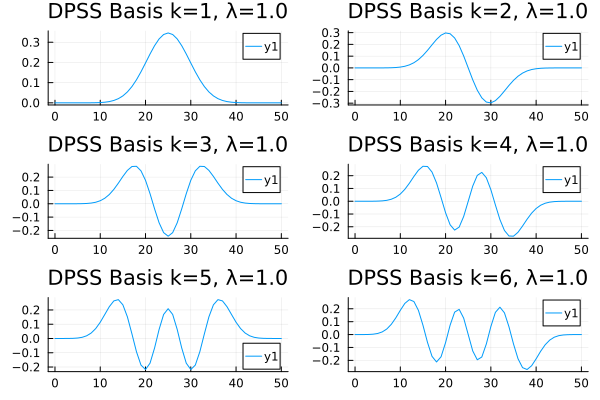

In [52]:
# plot the first few DPSS basis functions
plot(
    [plot(0:N, Φ[:, k], title="DPSS Basis k=$k, λ=$(round(eigenvalues[k], digits=4))") for k in 1:min(K, 6)]...,
    layout=(3, 2),
    size=(600, 400),
)


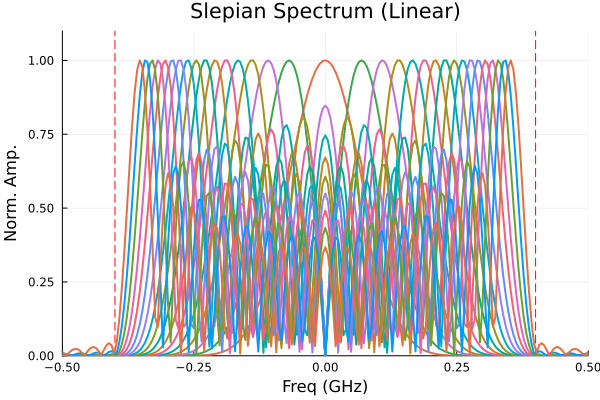

In [53]:
function get_spectrum_linear(signal, fs_physical)
    # 4x Padding for smoother visualization
    pad_len = 8 * length(signal)
    padded = zeros(Float64, pad_len)
    padded[1:length(signal)] = signal
    
    # FFT
    spec = fftshift(fft(padded))
    freqs = fftshift(fftfreq(pad_len, fs_physical))
    
    # Linear Magnitude (Normalized to 1.0)
    mag = abs.(spec)
    mag_norm = mag ./ maximum(mag)
    
    return freqs, mag_norm
end
# plot the fft of the first few DPSS basis functions to show their frequency localization
# --- Plot C: Slepian Frequency (Linear) ---
p3 = plot(title="Slepian Spectrum (Linear)", ylabel="Norm. Amp.", xlabel="Freq (GHz)", 
          ylims=(0, 1.1), xlims=(-0.5, 0.5), legend=false)

vline!(p3, [-B, B], color=:red, linestyle=:dash)

for k in 1:K
    f, m = get_spectrum_linear(dpss_basis[:,k], fs)
    plot!(p3, f, m, linewidth=2)
end
display(p3)

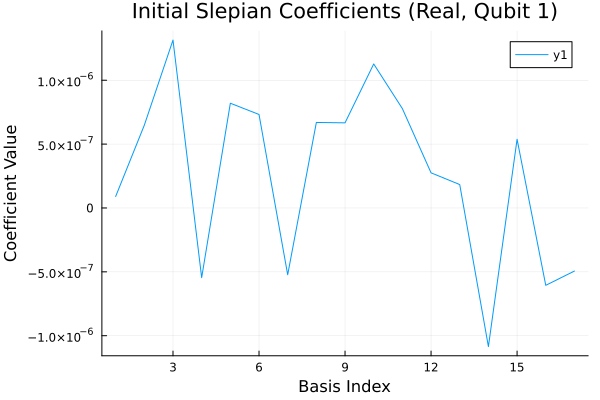

In [54]:
# ------------------------------------
# Initial pulse random guess setup #
# ------------------------------------
carrier_freqs = freqs
samples_matrix = Matrix{Float64}(undef, N + 1, n_qubits)
samples_matrix[1:N+1, :] .= 2π * 0.0000002 .* (2 .* rand(N + 1, n_qubits) .- 1)
samples_matrix = samples_matrix .+ im .* samples_matrix

# Project initial guess to Slepian basis
coeffs_initial_real = zeros(K, n_qubits)
coeffs_initial_imag = zeros(K, n_qubits)
for q in 1:n_qubits
    coeffs_initial_real[:, q] = Φ \ real(samples_matrix[:, q])
    coeffs_initial_imag[:, q] = Φ \ imag(samples_matrix[:, q])
end
coeffs_initial = vcat(vec(coeffs_initial_real), vec(coeffs_initial_imag))  # Flat initial vector
p1=plot(coeffs_initial_real[:, 1], title="Initial Slepian Coefficients (Real, Qubit 1)", xlabel="Basis Index", ylabel="Coefficient Value")


In [55]:
# ------------------------------
# Ground state (Hartree-Fock) #
# ------------------------------
initial_state_ground = "0011"
ψ_initial_g = zeros(ComplexF64, n_levels^n_qubits)
ψ_initial_g[1+parse(Int, initial_state_ground, base=n_levels)] = 1.0 + 0.0im
ψ_initial = copy(ψ_initial_g)

16-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [56]:
# -------------------------
# static Hamiltonian and drive operators 
# in the eigenbasis of the static Hamiltonian
# -------------------------
H_static = static_hamiltonian(device, n_levels)
drives = a_fullspace(n_qubits, n_levels)
eigvalues, eigvectors = eigen(Hermitian(H_static))
# println("Eignvalues of our static Hamiltonian")
# display(eigvalues)
tol_ode = 1e-6
Λ, U = eigs(Cost_ham)
E_actual = Λ[1]
println("Actual energy: $E_actual")

for i in 1:n_qubits
    drives[i] = eigvectors' * drives[i] * eigvectors
end

Actual energy: -7.881015714247044 + 9.368138416156402e-18im


#### 3. Forward Evolution (Schrödinger ODE)

Given a pulse $\Omega(t) = \Phi\,\vec c$ we solve

$$
i\,\dot\psi(t) \;=\; \hat H^{\text{IP}}(t)\,\psi(t), \qquad \psi(0)=|\psi_0\rangle,
$$

where the **interaction-picture Hamiltonian** (drift diagonal) is

$$
\hat H^{\text{IP}}(t) \;=\; e^{+i\hat H_0 t}\,\hat V(t)\, e^{-i\hat H_0 t},
\qquad
\hat V(t)\;=\;\sum_{q=1}^{n}\Omega_q(t)\,e^{+i\omega_q t}\,\hat a_q \;+\; \text{h.c.}
$$

This is exactly what [`dψdt!` in `src/evolution.jl`](../../src/evolution.jl#L22) evaluates:

```julia
for k in 1:n_sites
    amp  = amplitude(signals.channels[k], t)
    freq = frequency(signals.channels[k], t)
    H .+= amp * exp(im*freq*t) .* drives[k]
end
H .+= H'                                       # add hermitian conjugate  V(t)
device_action = exp.(im*t .* eigvalues)        # diagonal e^{iH₀t}
lmul!(Diagonal(device_action), H)              # e^{iH₀t} V(t)
rmul!(H, Diagonal(device_action)')             # e^{iH₀t} V(t) e^{-iH₀t}
dψ .= -im * H * ψ
```

[`evolve_ODE`](../../src/evolution.jl#L70) hands this RHS to `DifferentialEquations.jl` (RK4 integrator, tolerance `tol_ode`) and returns $|\psi(T)\rangle$ in the eigenbasis. The `basis="qubitbasis"` kwarg tells the solver the input $|\psi_0\rangle$ is expressed in the computational basis and should be rotated into/out of the eigenbasis at the ODE boundaries.



In [57]:
# ------------------------------------------------------------------
# ----- HELPER: RECONSTRUCT CONTROL PULSE FROM SLEPIAN COEFFS -----#
# ------------------------------------------------------------------
function coeffs_to_samples_matrix(coeffs::Vector{Float64})
    nK = K * n_qubits
    real_flat = coeffs[1:nK]
    imag_flat = coeffs[nK+1:end]
    coeffs_real = reshape(real_flat, K, n_qubits)
    coeffs_imag = reshape(imag_flat, K, n_qubits)
    samples_real = Φ * coeffs_real  
    samples_imag = Φ * coeffs_imag
    return samples_real .+ im .* samples_imag
end
# ------------------------------------------------------------------------------------------------
# ----- HELPER: APPLY LOW-PASS FILTER TO PULSE SAMPLES IN-PLACE -----
# This is in control basis, alternative to slepian basis projection. 
# We can compare the two approaches to see how much the low-pass filter changes the pulse compared to the slepian projection.
# ------------------------------------------------------------------------------------------------
function apply_lowpass!(samples_complex, sample_rate, filter_order, n_qubits)
    fs = 1 / sample_rate
    cutoff = fs / 2.0001

    # fft_before = Matrix{ComplexF64}(undef, size(samples_complex, 1), n_qubits)

    for i in 1:n_qubits
        pulse = samples_complex[:, i]
        # fft_before[:, i] = fft(pulse)
        filtered_pulse = SimpleEvolve.lowpass_filter(pulse, cutoff, fs; order=filter_order)
        # fft_after = fft(filtered_pulse)
        samples_complex[:, i] = filtered_pulse
    end

    return samples_complex
end

apply_lowpass! (generic function with 1 method)

#### 4. Cost Function

The bare objective is just the energy expectation value:

$$
E(\vec c) \;=\; \bigl\langle\psi(T;\vec c)\,\big|\,\hat H_{\text{mol}}\,\big|\,\psi(T;\vec c)\bigr\rangle
$$

implemented in [`costfunction_ode`](../../src/costfunction.jl#L19) as two lines:

```julia
ψ_ode = evolve_ODE(ψ0, T, signal, n_sites, drives, eigvals, eigvectors; basis, tol_ode)
return real(ψ_ode' * Cost_ham * ψ_ode), ψ_ode
```

To discourage the optimizer from handing back pulses the AWG cannot actually produce, we add a **soft amplitude penalty** from [`penaltyfunctions.jl`](../../src/penaltyfunctions.jl#L20):

$$
P(\Omega)\;=\;\sum_i p(x_i),\qquad x_i=\Omega_i/\Omega_0,\quad y_i=|x_i|-1
$$

$$
p(x_i)\;=\;\begin{cases} e^{\,y_i - 1/y_i} & y_i>0 \\ 0 & y_i\le 0\end{cases}
$$

$p(x)$ is **exactly zero** inside the soft wall $|\Omega_i|\le\Omega_0$, switches on smoothly just above it, and blows up super-polynomially as $|\Omega_i|$ grows; a "one-sided infinite wall". The penalty is $C^\infty$ at $y=0$, so the gradient stays well-behaved.

The cost used by the optimizer (`costfunction_ode_with_penalty`, toggled by the `penalty = true` flag below) is

$$
\boxed{\;\mathcal{L}(\vec c) \;=\; E(\vec c) \;+\; \lambda\, P\!\bigl(\Omega(\vec c)\bigr),\qquad \Omega_0 = 2\pi \cdot 0.02 \text{ GHz},\quad \lambda=1.\;}
$$

In [58]:
# --------------------------------------------------------------
# ----- COST FUNCTION FOR OPTIMIZATION (SLEPIAN COEFFS AS VARIABLES) -----
# --------------------------------------------------------------
function costfunction_coeffs(coeffs::Vector{Float64})
    samples_complex = coeffs_to_samples_matrix(coeffs)
    signals = MultiChannelSignal([DigitizedSignal(samples_complex[:, i], δt, carrier_freqs[i]) for i in 1:n_qubits])
    if penalty
        energy, Ψ_ode = SimpleEvolve.costfunction_ode_with_penalty(
            ψ_initial, eigvalues, signals, n_qubits, drives, eigvectors, T, Cost_ham;
            basis="qubitbasis", tol_ode=tol_ode)
    else
        energy, Ψ_ode = SimpleEvolve.costfunction_ode(
            ψ_initial, eigvalues, signals, n_qubits, drives, eigvectors, T, Cost_ham;
            basis="qubitbasis", tol_ode=tol_ode
        )
    end
    return energy
end

costfunction_coeffs (generic function with 1 method)

#### 5. Gradient via the Krotov Method

A naïve finite-difference would cost $2\,d$ ODE solves per gradient, where $d=136$. The adjoint method computes the **entire gradient in two ODE solves**, independent of $d$.

### 5.1  Adjoint state

Define the backward ("co-state") $\sigma(t) \in \mathbb{C}^D$ by solving the **same Schrödinger ODE** with terminal condition

$$
\sigma(T) \;=\; \hat H_{\text{mol}}\,\psi(T),
$$

and then propagating *backwards* from $T$ to $0$. Intuitively $\sigma(t)$ carries the sensitivity of the final-time cost to the wavefunction at time $t$.

### 5.2  Sample-wise gradient formula

For a piecewise-constant parameterization with $N$ samples (step size $\tau = T/N$) the gradient of $E$ w.r.t. one pulse sample is

$$
\boxed{\;
\frac{\partial E}{\partial \Omega^{\mathrm{Re}}_{q,i}} \;=\; 2\,\mathrm{Re}\!\left[\,-i\,\tau\,\bigl\langle\sigma(t_i)\,\big|\,\partial_{\Omega^{\mathrm{Re}}}\hat H^{\text{IP}}(t_i)\,\big|\,\psi(t_i)\bigr\rangle\,\right]
\;}
$$

and similarly for the imaginary part. The operator derivatives are

$$
\partial_{\Omega^{\mathrm{Re}}}\hat H^{\text{IP}}(t) \;=\; A_q(t)+A_q^\dagger(t),\qquad
\partial_{\Omega^{\mathrm{Im}}}\hat H^{\text{IP}}(t) \;=\; i\bigl(A_q(t)-A_q^\dagger(t)\bigr),
$$

$$
A_q(t) = e^{+i\hat H_0 t}\bigl[e^{+i\omega_q t}\hat a_q\bigr]e^{-i\hat H_0 t}
$$
 — the "interaction-picture drive" for channel $q$. This is precisely [`gradient_eachtimestep!` in `src/gradient.jl`](../../src/gradient.jl#L227):

```julia
term         = exp(im * frequency(…) * t) .* drives[k]
dH_dΩ_real  .= term + term'                      # ∂V/∂Ω_Re
dH_dΩ_imag  .= im * term - im * term'            # ∂V/∂Ω_Im
device_action = exp.(im*t .* eigvalues)          # e^{iH₀t}
lmul!(Diagonal(device_action), dH_dΩ_real)       # interaction-picture rotate
rmul!(dH_dΩ_real, Diagonal(device_action)')
σAψ_real   = -im * (σ' * dH_dΩ_real * ψ) * τ
∂Ω_real[i,k] = 2 * real(σAψ_real)
```

### 5.3  Full procedure

[`gradientsignal_ODE`](../../src/gradient.jl#L24) packages the whole thing into four steps:

1. **Forward evolve** $\psi(0)\to\psi(T)$ (reuses the same ODE solver as the cost).

2. Apply $\hat H_{\text{mol}}$ to get $\sigma(T)$, rotate from qubit basis → eigenbasis.

3. **Backward evolve** $\sigma(T)\to\sigma(0)$ (same ODE, reversed time span).

4. **Sweep forward** from $t_0$ to $t_N$ again, carrying *both* $\psi$ and $\sigma$, and at every $t_i$ call `gradient_eachtimestep!` to fill the $(N{+}1)\times n_q$ matrices $\partial E/\partial\Omega^{\mathrm{Re}}$ and $\partial E/\partial\Omega^{\mathrm{Im}}$.

### 5.4  Chain rule back to Slepian coefficients

Because $\Omega = \Phi\,c$ is linear, the gradient w.r.t. the $(K, n_q)$ coefficient matrix is one small matrix multiplication:

$$
\frac{\partial E}{\partial c^{\mathrm{Re}}_{k,q}} \;=\; \sum_{n=0}^{N}\Phi_{n,k}\,\frac{\partial E}{\partial \Omega^{\mathrm{Re}}_{n,q}}
\;\;\Longleftrightarrow\;\;
\bigl[\partial_c E\bigr]^{\mathrm{Re}} = \Phi^\top\,\bigl[\partial_\Omega E\bigr]^{\mathrm{Re}}.
$$

Which is the

```julia
grad_real = Φ' * ∂Ω_real
grad_imag = Φ' * ∂Ω_imag
```

line in `gradient_coeffs!` below. The penalty gradient (analytic derivative of $p(x)$ above, implemented in the same cell) is added on top, then the two halves are `vcat`'d into the flat $2Kn_q$-vector L-BFGS expects.

In [59]:
# --------------------------------------------------------------
# ----- GRADIENT FUNCTION FOR OPTIMIZATION (SLEPIAN COEFFS AS VARIABLES) -----
# --------------------------------------------------------------

function gradient_coeffs!(Grad::Vector{Float64}, coeffs::Vector{Float64}; Ω₀=2π * 0.02, λ=1.0)
    samples_complex = coeffs_to_samples_matrix(coeffs)
    signals = MultiChannelSignal([
        DigitizedSignal(samples_complex[:, i], δt, carrier_freqs[i])
        for i in 1:n_qubits
    ])
    ∂Ω_real, ∂Ω_imag, ψ_ode, σ_ode = SimpleEvolve.gradientsignal_ODE(
        ψ_initial, T, signals, n_qubits, drives, eigvalues, eigvectors,
        Cost_ham, n_samples;
        basis="qubitbasis", tol_ode=tol_ode
    )
    grad_real = Φ' * ∂Ω_real
    grad_imag = Φ' * ∂Ω_imag
    grad_vec = vcat(vec(grad_real), vec(grad_imag))
    if penalty
        samples_flat = vec(samples_complex)
        sample_penalty_grad = zeros(ComplexF64, size(samples_complex))
        for q in 1:n_qubits
            for ti in 1:N+1
                x = samples_complex[ti, q] / Ω₀
                y = abs(x) - 1
                g = 0
                if y > 0
                    h = exp(y - 1 / y)
                    dh_dmag = h * (1 + 1 / y^2) / Ω₀
                    g = dh_dmag * (x / max(abs(x), eps()))
                end
                sample_penalty_grad[ti, q] = g
            end
        end
        sample_pen_real = real(sample_penalty_grad)
        sample_pen_imag = imag(sample_penalty_grad)
        pen_coeffs_real = Φ' * sample_pen_real
        pen_coeffs_imag = Φ' * sample_pen_imag
        grad_vec .+= λ * vcat(vec(pen_coeffs_real), vec(pen_coeffs_imag))
    end
    Grad .= grad_vec
    return Grad
end

gradient_coeffs! (generic function with 1 method)

In [60]:
# --------------------------------------------------------------
# ----- TEST COST FUNCTION AND GRADIENT WITH SLEPIAN COEFFS AS VARIABLES
# --------------------------------------------------------------
tol_ode = 1e-6
penalty = true
@time energy_hf = costfunction_coeffs(zeros(length(coeffs_initial)))
println("Hartree Fock energy ", energy_hf)
@time energy1 = costfunction_coeffs(coeffs_initial)
println("initial energy ", energy1)


  0.019665 seconds (40.72 k allocations: 2.405 MiB, 94.83% compilation time)
Hartree Fock energy -7.863357619999981
  0.000825 seconds (6.20 k allocations: 1.188 MiB)
initial energy -7.863357616265825


In [61]:
COST_THRESHOLD = 1e4
function safe_cost(x)
    val = costfunction_coeffs(x)
    if !isfinite(val) || val > COST_THRESHOLD
        println("Exiting: cost too large ($val)")
        return Inf
    end
    return val
end
function safe_gradient!(g, x)
    val = costfunction_coeffs(x)
    if !isfinite(val) || val > COST_THRESHOLD
        println("Exiting in gradient: cost too large ($val)")
        fill!(g, Inf)
        return Inf
    end
    gradient_coeffs!(g, x)
end

safe_gradient! (generic function with 1 method)

#### 6. L-BFGS with Safety Wrappers and Tolerance Ramping

We feed the cost and gradient to `Optim.jl`'s **limited-memory BFGS** with a **More-Thuente line search**. L-BFGS approximates the inverse Hessian from a sliding window of recent gradient differences; it typically converges in 20–100 iterations for a problem of this size without ever building the full Hessian.

The `safe_cost` / `safe_gradient!` wrappers added above trap NaN/Inf and pathologically-large cost values: if the line search ever walks into a region where the ODE solver blows up (which can happen when the penalty drives amplitudes to unphysical values), we bail out with `Inf` rather than letting `Optim` propagate garbage derivatives.

**Three practical tricks used in the cell below:**

1. **ODE-tolerance ramp.** Each outer L-BFGS restart runs at progressively tighter `tol_ode`: $10^{-6} \to 10^{-8} \to 10^{-10}$. Loose tolerance finds the basin cheaply; tight tolerance refines the last few digits inside it. You avoid paying for high-precision ODEs during the initial large steps.

2. **Warm restart.** Each outer loop is initialized from the previous loop's minimizer (`coeffs_final0 → coeffs_final1 → coeffs_final2 → coeffs_final`). The internal L-BFGS Hessian-memory is re-seeded but the parameter vector is preserved, which is usually enough to resume good conditioning.

3. **Penalty homotopy (optional).** If the optimizer keeps escaping the amplitude wall, ramp $\lambda$ upward between outer loops. We use $\lambda=1$ throughout here — LiH-1.5 on 4 qubits at $T=25$ ns with $\Omega_0=2\pi\cdot 0.02$ doesn't need homotopy to stay in-bound.

**Convergence check.** After the four outer loops finish, `coeffs_final` is a stationary point of $\mathcal{L}$. The quality check below reports:

- `Final energy` — $\mathcal{L}(\vec c^\star)$, which is $E$ minus the (zero) penalty contribution when the pulse is in-bound.
- `Final gradient norm` — should be $\lesssim 10^{-5}$ for tight convergence.
- `Final gap to actual` — $\mathcal{L}(\vec c^\star) - E_\text{exact}$, should be close to zero. For LiH at equilibrium this is typically $\sim 10^{-9}$ Ha when the Slepian basis is rich enough to represent the optimal pulse.

In [62]:
linesearch = LineSearches.MoreThuente()
optimizer = Optim.LBFGS(linesearch=linesearch)
options = Optim.Options(
                show_trace = true,
                show_every = 1,
                f_reltol   = 1e-15,
                g_tol      = 1e-6,
                iterations = 1000,
            )


                x_abstol = 0.0
                x_reltol = 0.0
                f_abstol = 0.0
                f_reltol = 1.0e-15
                g_abstol = 1.0e-6
          outer_x_abstol = 0.0
          outer_x_reltol = 0.0
          outer_f_abstol = 0.0
          outer_f_reltol = 0.0
          outer_g_abstol = 1.0e-8
           f_calls_limit = 0
           g_calls_limit = 0
           h_calls_limit = 0
       allow_f_increases = true
 allow_outer_f_increases = true
        successive_f_tol = 1
              iterations = 1000
        outer_iterations = 1000
             store_trace = false
           trace_simplex = false
              show_trace = true
          extended_trace = false
           show_warnings = true
              show_every = 1
                callback = nothing
              time_limit = NaN


In [63]:
tol_ode = 1e-6
optimization = Optim.optimize(safe_cost, safe_gradient!, coeffs_initial, optimizer, options)
coeffs_final0 = Optim.minimizer(optimization)

val0 = costfunction_coeffs(coeffs_final0)

tol_ode = 1e-8
optimization = Optim.optimize(safe_cost, safe_gradient!, coeffs_final0, optimizer, options)
coeffs_final1 = Optim.minimizer(optimization)


val1 = costfunction_coeffs(coeffs_final1)
tol_ode = 1e-10
optimization = Optim.optimize(safe_cost, safe_gradient!, coeffs_final1, optimizer, options)
coeffs_final2 = Optim.minimizer(optimization)

optimization = Optim.optimize(safe_cost, safe_gradient!, coeffs_final2, optimizer, options)
coeffs_final = Optim.minimizer(optimization)


Iter     Function value   Gradient norm 
     0    -7.863358e+00     7.009314e-03
 * time: 7.104873657226562e-5
     1    -7.864396e+00     1.086407e-02
 * time: 0.07848405838012695
     2    -7.865523e+00     4.761259e-03
 * time: 0.11370491981506348
     3    -7.865948e+00     3.301288e-03
 * time: 0.1503000259399414
     4    -7.866540e+00     3.693845e-03
 * time: 0.18977093696594238
     5    -7.867130e+00     4.714730e-03
 * time: 0.230010986328125
     6    -7.867358e+00     2.745930e-03
 * time: 0.31502485275268555
     7    -7.867517e+00     1.633403e-03
 * time: 0.35912084579467773
     8    -7.867723e+00     2.559816e-03
 * time: 0.3998689651489258
     9    -7.868039e+00     4.958058e-03
 * time: 0.44625282287597656
    10    -7.868734e+00     7.344460e-03
 * time: 0.49741101264953613
    11    -7.869719e+00     7.520917e-03
 * time: 0.5567598342895508
    12    -7.871382e+00     8.810383e-03
 * time: 0.6188828945159912
    13    -7.872104e+00     1.335383e-02
 * time: 0.68

136-element Vector{Float64}:
 -0.024499248751283842
  0.10765398864492666
  0.051901936963952684
  0.017138202814570448
  0.020143417513595326
  0.027044675577516344
  0.009677276579740025
  0.028742934991071407
  0.011757500420812148
  0.01135358052919819
  0.023106708794228294
 -0.006512621822977488
  0.032926341370650994
  ⋮
  0.046001983393818016
  0.05534214988659582
  0.03891842614434151
  0.030217355055230873
  0.007834435455847458
  0.00941185193554441
 -0.010669254658024098
 -0.0050296831251779835
 -0.01491365388837676
 -0.016033555849968368
 -0.01076004871944514
 -0.023519869466985654

In [64]:
Grad = zeros(Float64, 2 * K * n_qubits)
samples_final = coeffs_to_samples_matrix(coeffs_final)
final_energy = costfunction_coeffs(coeffs_final)
final_gradient = gradient_coeffs!(Grad, coeffs_final)
println("Optimization complete for K=$K, N=$N, W=$W, T=$T, seed=$seed, fs=$fs")
println("Final energy: ", final_energy)
println("Final gradient norm: ", norm(final_gradient))
println("Final gap to actual: ", final_energy - real(E_actual))


Optimization complete for K=17, N=50, W=0.2, T=25.0, seed=1234, fs=2.0
Final energy: -7.881015713210061
Final gradient norm: 3.155343755101037e-6
Final gap to actual: 1.0369829439582645e-9


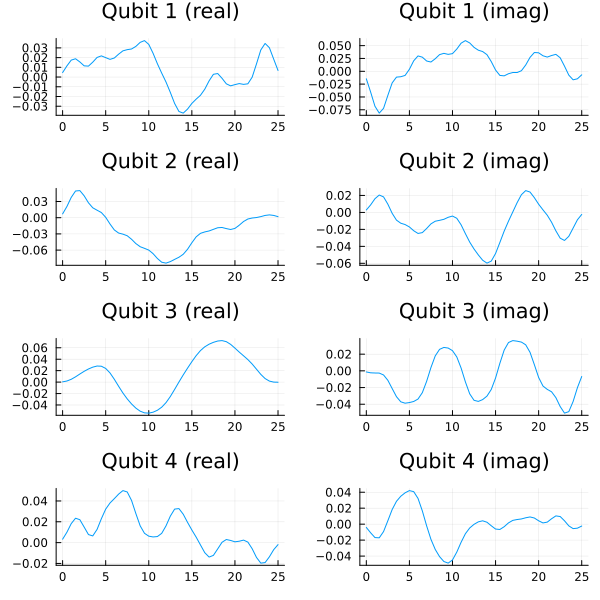

In [65]:
Ω = samples_final
pulse_windows = range(0, T, length = N+1)

Ω_plots = plot(
    [plot(pulse_windows, real.(Ω[:, q]), title = "Qubit $q (real)")
     for q in 1:n_qubits]...,
    legend = false, layout = (n_qubits, 1))

Ω_plots_final = plot(
    [plot(pulse_windows, imag.(Ω[:, q]), title = "Qubit $q (imag)")
     for q in 1:n_qubits]...,
    legend = false, layout = (n_qubits, 1))

plot(Ω_plots, Ω_plots_final, layout = (1, 2), size = (600, 150*n_qubits))


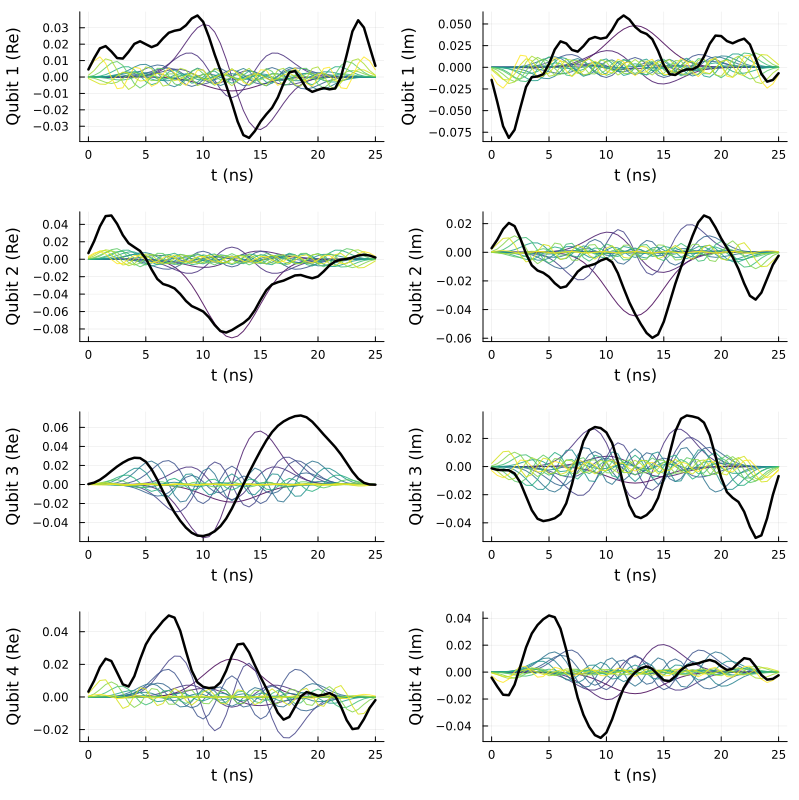

In [66]:
# ---------------------------------------------------------
# Weighted Slepian components  cᵢ · φᵢ(t)  per qubit
# ---------------------------------------------------------
# For each qubit q, overlay all K weighted DPSS modes:
#       cᵢ_real(q) · φᵢ(t)    (top strip)
#       cᵢ_imag(q) · φᵢ(t)    (bottom strip)
# The bold black curve is the sum — same as Ω[:, q] (reconstructed pulse).

nK          = K * n_qubits
coeffs_real = reshape(coeffs_final[1:nK],     K, n_qubits)
coeffs_imag = reshape(coeffs_final[nK+1:end], K, n_qubits)

pulse_windows = range(0, T, length = N + 1)
palette_k     = palette(:viridis, K)     # one colour per Slepian mode

function weighted_slepian_plot(coeffs_q, total_q, lbl)
    p = plot(xlabel = "t (ns)", ylabel = lbl, legend = false)
    for k in 1:K
        plot!(p, pulse_windows, coeffs_q[k] .* Φ[:, k],
              lw = 1, color = palette_k[k], alpha = 0.85)
    end
    # Reconstructed total (sum over k) — matches Ω[:,q]
    plot!(p, pulse_windows, total_q,
          lw = 2.5, color = :black, label = "sum")
    return p
end

re_panels = [weighted_slepian_plot(coeffs_real[:, q], real.(Ω[:, q]),
                                   "Qubit $q (Re)")
             for q in 1:n_qubits]
im_panels = [weighted_slepian_plot(coeffs_imag[:, q], imag.(Ω[:, q]),
                                   "Qubit $q (Im)")
             for q in 1:n_qubits]

plot(plot(re_panels..., layout = (n_qubits, 1)),
     plot(im_panels..., layout = (n_qubits, 1)),
     layout = (1, 2), size = (800, 200 * n_qubits))


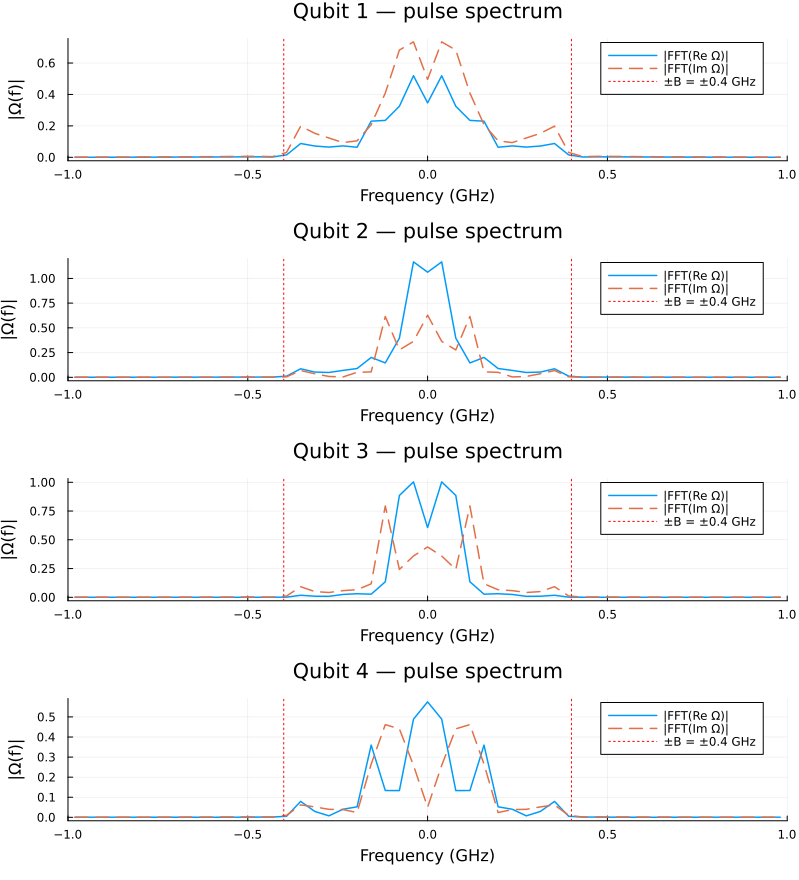

In [67]:
# ---------------------------------------------------------
# Frequency-domain analysis of the optimized pulses
# ---------------------------------------------------------
# fs (samples per ns) → FFT frequencies are in GHz.
# The Slepian basis is spectrally concentrated on [-W, +W] in normalized
# units, which in physical frequency is [-B, +B]. The spectra below should
# essentially vanish outside that window — a direct consistency check of
# the DPSS bandlimit.

freq_axis = fftshift(fftfreq(N + 1, fs))   # GHz

spec_plots = Vector{Plots.Plot}(undef, n_qubits)
for q in 1:n_qubits
    Xr = fftshift(abs.(fft(real.(Ω[:, q]))))
    Xi = fftshift(abs.(fft(imag.(Ω[:, q]))))
    p  = plot(freq_axis, Xr,  lw = 1.5, label = "|FFT(Re Ω)|")
    plot!(p, freq_axis, Xi,  lw = 1.5, ls = :dash,  label = "|FFT(Im Ω)|")
    vline!(p, [-B, B],       lw = 1.0, ls = :dot,   color = :red,
           label = "±B = ±$B GHz")
    xlabel!(p, "Frequency (GHz)")
    ylabel!(p, "|Ω(f)|")
    title!(p,  "Qubit $q — pulse spectrum")
    xlims!(p, -fs/2, fs/2)
    spec_plots[q] = p
end
plot(spec_plots..., layout = (n_qubits, 1),
     size = (800, 220*n_qubits), legend = :topright)

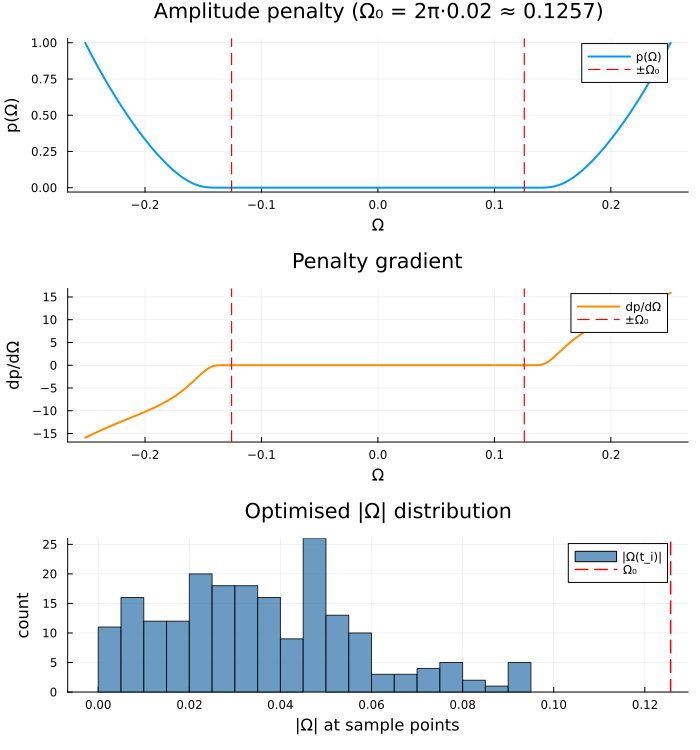

In [68]:
# ---------------------------------------------------------
# Penalty function visualisation
# ---------------------------------------------------------
# p(x) = exp(y - 1/y) for y = |x|-1 > 0,  x = Ω/Ω₀,   else 0.
# Zero inside the soft wall |Ω| ≤ Ω₀, smoothly turns on just outside it,
# and grows super-polynomially. C^∞ at the wall, so the gradient is well-behaved.

Ω₀ = 2π * 0.02                       # same wall used in the optimisation
p_scalar(Ω) = begin
    x = Ω / Ω₀
    y = abs(x) - 1
    y > 0 ? exp(y - 1 / y) : 0.0
end
dp_scalar(Ω) = begin
    x = Ω / Ω₀
    y = abs(x) - 1
    y > 0 ? sign(x) * exp(y - 1 / y) * (1 + 1 / y^2) / Ω₀ : 0.0
end

Ω_grid = range(-2.0Ω₀, 2.0Ω₀; length = 1001)
p_vals  = p_scalar.(Ω_grid)
dp_vals = dp_scalar.(Ω_grid)

p_pen = plot(Ω_grid, p_vals,
             lw = 2, label = "p(Ω)",
             xlabel = "Ω", ylabel = "p(Ω)",
             title = "Amplitude penalty (Ω₀ = 2π·0.02 ≈ $(round(Ω₀, digits=4)))")
vline!(p_pen, [-Ω₀, Ω₀], lw = 1.2, ls = :dash, color = :red,
       label = "±Ω₀")

p_grad = plot(Ω_grid, dp_vals,
              lw = 2, color = :darkorange, label = "dp/dΩ",
              xlabel = "Ω", ylabel = "dp/dΩ",
              title = "Penalty gradient")
vline!(p_grad, [-Ω₀, Ω₀], lw = 1.2, ls = :dash, color = :red, label = "±Ω₀")

# Overlay the actual sample amplitudes from the optimised pulse so we can
# see whether the optimiser is brushing the wall or sitting comfortably inside.
amps = vec(abs.(samples_final))
p_hist = histogram(amps, bins = 40,
                   xlabel = "|Ω| at sample points", ylabel = "count",
                   title = "Optimised |Ω| distribution",
                   label = "|Ω(t_i)|", color = :steelblue, alpha = 0.8)
vline!(p_hist, [Ω₀], lw = 1.5, ls = :dash, color = :red, label = "Ω₀")

plot(p_pen, p_grad, p_hist, layout = (3, 1), size = (700, 750), legend = :topright)
